In [1]:

import os
import glob
import zipfile
from pathlib import Path

import pandas as pd
import geopandas as gpd
import pyreadstat
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


HR_IR_ZIP_DIR = Path(r"C:\Users\user\Desktop\HRandIRzips")
GPS_DIR       = Path(r"C:\Users\user\Desktop\GPSzips")
OUT_DIR       = Path(r"C:\Users\user\Desktop\DHS_merged_output")


OUT_DIR.mkdir(parents=True, exist_ok=True)

# Unzip all HR/IR and GPS zips
def unzip_all(zip_dir: Path):
    for zpath in zip_dir.glob("*.zip"):
        folder = zip_dir / zpath.stem
        if folder.exists():
            print(f"Already unzipped: {zpath.name}")
            continue
        try:
            with zipfile.ZipFile(zpath, "r") as zf:
                folder.mkdir(exist_ok=True)
                zf.extractall(folder)
            print(f"Unzipped: {zpath.name}")
        except Exception as e:
            print(f"Failed to unzip {zpath.name}: {e}")

unzip_all(HR_IR_ZIP_DIR)
unzip_all(GPS_DIR)

Already unzipped: ALHR71DT.ZIP
Already unzipped: ALIR71DT.ZIP
Already unzipped: AMHR72DT.ZIP
Already unzipped: AMIR72DT.ZIP
Already unzipped: AOHR81DT.ZIP
Already unzipped: AOIR81DT.ZIP
Already unzipped: BFHR81DT.ZIP
Already unzipped: BFIR81DT.ZIP
Already unzipped: BJHR71DT.ZIP
Already unzipped: BJIR71DT.ZIP
Already unzipped: BUHR71DT.ZIP
Already unzipped: BUIR71DT.ZIP
Already unzipped: CDHR81DT.ZIP
Already unzipped: CDIR81DT.ZIP
Already unzipped: CFHR31DT.ZIP
Already unzipped: CFIR31DT.ZIP
Already unzipped: CIHR81DT.ZIP
Already unzipped: CIIR81DT.ZIP
Already unzipped: CMHR71DT.ZIP
Already unzipped: CMIR71DT.ZIP
Already unzipped: COHR72DT.ZIP
Already unzipped: COIR72DT.ZIP
Already unzipped: DRHR61DT.ZIP
Already unzipped: DRHR6ADT.ZIP
Already unzipped: DRIR61DT.ZIP
Already unzipped: DRIR6ADT.ZIP
Already unzipped: EGHR61DT.ZIP
Already unzipped: EGIR61DT.ZIP
Already unzipped: ETHR81DT.ZIP
Already unzipped: ETIR81DT.ZIP
Already unzipped: GAHR71DT.ZIP
Already unzipped: GAIR71DT.ZIP
Already 

In [2]:

# CELL 2 — EXTRACT WEALTH SCORES & MERGE WITH GPS
# Reads HR (Household Recode) or IR (Individual Recode) files
# and merges cluster-level wealth with GPS coordinates


OUT_FILE = OUT_DIR / "all_countries_gps_wealth.gpkg"

if OUT_FILE.exists():
    print("Merged dataset already exists — skipping extraction.")

else:
    print("Running wealth extraction...")

    def read_dhs(path: Path):
        if path.suffix.lower() == ".dta":
            df, _ = pyreadstat.read_dta(str(path))
        elif path.suffix.lower() == ".sav":
            df, _ = pyreadstat.read_sav(str(path))
        else:
            raise ValueError(f"Unsupported file type: {path.suffix}")
        return df

    def extract_hr(path):
        """Extract cluster-level wealth from Household Recode (HR) file."""
        df = read_dhs(path)
        cols = [c for c in df.columns if c.lower() in ["hv001", "hv270", "hv271"]]
        df = df[cols].rename(columns=str.lower)
        agg = df.groupby("hv001", as_index=False).agg(
            wealth_quintile=("hv270", "mean"),
            wealth_score=("hv271", "mean")
        )
        agg.rename(columns={"hv001": "DHSCLUST"}, inplace=True)
        return agg

    def extract_ir(path):
        """Extract cluster-level wealth from Individual Recode (IR) file."""
        df = read_dhs(path)
        cols = [c for c in df.columns if c.lower() in ["v001", "v190", "v191"]]
        df = df[cols].rename(columns=str.lower)
        agg = df.groupby("v001", as_index=False).agg(
            wealth_quintile=("v190", "mean"),
            wealth_score=("v191", "mean")
        )
        agg.rename(columns={"v001": "DHSCLUST"}, inplace=True)
        return agg

    # Build wealth dict per country — HR preferred, IR as fallback
    country_wealth = {}

    for folder in sorted(HR_IR_ZIP_DIR.iterdir()):
        if not folder.is_dir():
            continue
        hr_files = list(folder.glob("*HR*.dta")) + list(folder.glob("*HR*.sav"))
        ir_files = list(folder.glob("*IR*.dta")) + list(folder.glob("*IR*.sav"))

        country_code = folder.name[:2].upper()

        if hr_files:
            try:
                country_wealth[country_code] = extract_hr(hr_files[0])
                print(f"HR: {folder.name} → {len(country_wealth[country_code])} clusters")
            except Exception as e:
                print(f"HR failed for {folder.name}: {e}")
        elif ir_files:
            try:
                country_wealth[country_code] = extract_ir(ir_files[0])
                print(f"IR: {folder.name} → {len(country_wealth[country_code])} clusters")
            except Exception as e:
                print(f"IR failed for {folder.name}: {e}")
        else:
            print(f"No HR/IR file found in {folder.name}")

    # Merge wealth with GPS shapefiles
    merged_list = []

    for folder in sorted(GPS_DIR.iterdir()):
        if not folder.is_dir():
            continue
        shp_files = list(folder.glob("*.shp"))
        if not shp_files:
            continue

        country_code = folder.name[:2].upper()
        if country_code not in country_wealth:
            print(f"No wealth data for {country_code}, skipping")
            continue

        try:
            gps = gpd.read_file(shp_files[0])
            gps = gps.rename(columns={"DHSCLUST": "DHSCLUST"})
            merged = gps.merge(country_wealth[country_code], on="DHSCLUST", how="left")
            merged["country"] = country_code
            merged_list.append(merged)
            print(f"Merged {country_code}: {len(merged)} clusters")
        except Exception as e:
            print(f"GPS merge failed for {folder.name}: {e}")

    if merged_list:
        all_merged = pd.concat(merged_list, ignore_index=True)
        all_merged.to_file(OUT_FILE, driver="GPKG")
        all_merged.drop(columns="geometry").to_csv(
            OUT_DIR / "all_countries_gps_wealth.csv", index=False)
        print(f"\nSaved: {len(all_merged):,} total clusters across {len(merged_list)} countries")
    else:
        print("No datasets merged — check your folder structure")

Merged dataset already exists — skipping extraction.


C:\Users\makis\povertysetvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total clusters: 33,480
Countries: 45
Columns: ['DHSID', 'DHSCC', 'DHSYEAR', 'DHSCLUST', 'CCFIPS', 'ADM1FIPS', 'ADM1FIPSNA', 'ADM1SALBNA', 'ADM1SALBCO', 'ADM1DHS', 'ADM1NAME', 'DHSREGCO', 'DHSREGNA', 'SOURCE', 'URBAN_RURA', 'LATNUM', 'LONGNUM', 'ALT_GPS', 'ALT_DEM', 'DATUM', 'wealth_quintile', 'wealth_score', 'country', 'geometry']


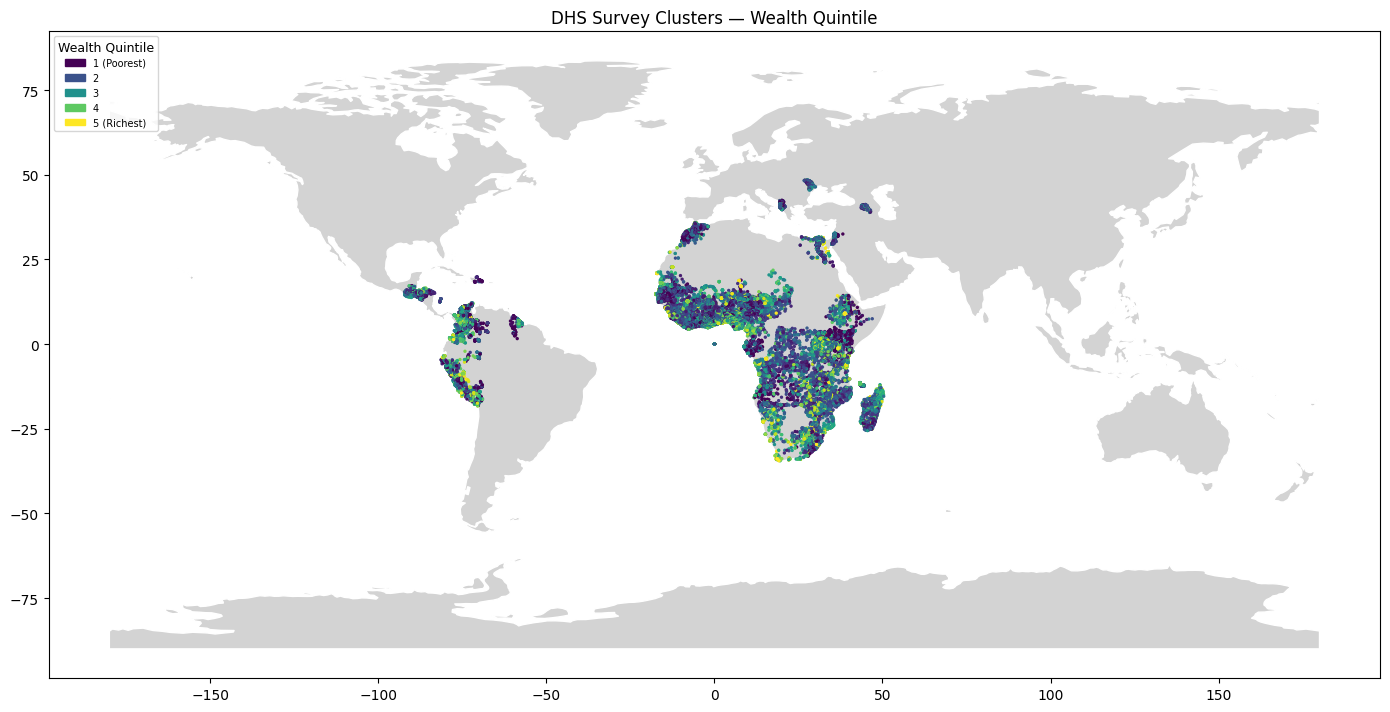

In [3]:

# CELL 3 — LOAD & VISUALIZE DHS WEALTH POINTS
import geodatasets
gdf = gpd.read_file(OUT_DIR / "all_countries_gps_wealth.gpkg")

print(f"Total clusters: {len(gdf):,}")
print(f"Countries: {gdf['country'].nunique()}")
print(f"Columns: {gdf.columns.tolist()}")

world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

fig, ax = plt.subplots(figsize=(14, 8))
world.plot(ax=ax, color="lightgray", edgecolor="white")

gdf.plot(
    ax=ax,
    column="wealth_quintile",
    cmap="viridis",
    markersize=2,
    legend=False
)

cmap   = plt.cm.viridis
colors = cmap(np.linspace(0, 1, 5))
labels = ["1 (Poorest)", "2", "3", "4", "5 (Richest)"]
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(5)]

plt.legend(handles=patches, title="Wealth Quintile",
           loc="upper left", fontsize=7, title_fontsize=9)
plt.title("DHS Survey Clusters — Wealth Quintile")
plt.tight_layout()
plt.show()

In [4]:

# CELL 4 — EXPORT TO CSV & GEOJSON

gdf["lon"] = gdf.geometry.x
gdf["lat"]  = gdf.geometry.y


gdf.drop(columns="geometry").to_csv("dhs_points.csv", index=False)

# GeoJSON — optional, useful for QGIS or local inspection
gdf.to_file("dhs_points.geojson", driver="GeoJSON")

print(f"Exported {len(gdf):,} clusters to dhs_points.csv and dhs_points.geojson")
print("Next step: upload dhs_points.csv to Google Earth Engine as a table asset")

Exported 33,480 clusters to dhs_points.csv and dhs_points.geojson
Next step: upload dhs_points.csv to Google Earth Engine as a table asset


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import json
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler


In [6]:
files = glob.glob(r'C:\Users\makis\Downloads\DHS_FEATURES_BY_YEAR\dhs_features_year_*.csv')
print(f"Found {len(files)} year files")


Found 18 year files


In [7]:
dfs= []
for f in files:
    df_temp = pd.read_csv(f)
    dfs.append(df_temp)
    print(f"  {f.split('_')[-1].replace('.csv','')}: {len(df_temp):,} rows")

  2003: 17,631 rows
  2005: 18,073 rows


C:\Users\makis\AppData\Local\Temp\ipykernel_14008\2655292983.py:3: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(f)


  2009: 43,098 rows
  2010: 143,535 rows
  2011: 49,104 rows
  2012: 23,993 rows
  2013: 58,162 rows
  2014: 71,795 rows
  2015: 68,195 rows
  2016: 53,474 rows
  2017: 86,176 rows
  2018: 31,573 rows
  2019: 70,096 rows
  2020: 26,589 rows
  2021: 71,322 rows
  2022: 152,520 rows
  2023: 126,740 rows
  2024: 117,602 rows


In [8]:
dfs[1].head()

,system:index,ADM1DHS,ADM1FIPS,ADM1FIPSNA,ADM1NAME,ADM1SALBCO,ADM1SALBNA,ALT_DEM,ALT_GPS,CCFIPS,...,red_mean,red_std,slope,swir1_mean,swir1_std,swir2_mean,swir2_std,wealth_quintile,wealth_score,.geo
0,000000000000000052e8_0,9999.0,NaN,NaN,NaN,NaN,NaN,111.0,62.0,MD,...,1599.876812,2208.253768,1.163305,2311.920290,597.016447,1512.818841,561.216410,1.733333,-102708.733333,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,000000000000000052e8_1,9999.0,NaN,NaN,NaN,NaN,NaN,111.0,62.0,MD,...,1599.760870,2169.470384,1.910243,2358.014493,574.883756,1570.123188,556.718276,1.733333,-102708.733333,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,000000000000000052e8_2,9999.0,NaN,NaN,NaN,NaN,NaN,111.0,62.0,MD,...,1584.847826,2139.297216,2.483545,2296.137681,579.257135,1501.623188,524.685733,1.733333,-102708.733333,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,000000000000000052e8_3,9999.0,NaN,NaN,NaN,NaN,NaN,111.0,62.0,MD,...,1584.847826,2139.297216,2.688055,2296.137681,579.257135,1501.623188,524.685733,1.733333,-102708.733333,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,000000000000000052e8_4,9999.0,NaN,NaN,NaN,NaN,NaN,111.0,62.0,MD,...,1524.289855,2016.586308,1.284385,2139.072464,602.852442,1333.427536,515.375688,1.733333,-102708.733333,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [9]:
df = pd.concat(dfs, ignore_index= True)
print(f"\nTotal rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")


Total rows: 1,229,678
Columns: ['system:index', 'ADM1DHS', 'ADM1FIPS', 'ADM1FIPSNA', 'ADM1NAME', 'ADM1SALBCO', 'ADM1SALBNA', 'ALT_DEM', 'ALT_GPS', 'CCFIPS', 'DATUM', 'DHSCC', 'DHSCLUST', 'DHSID', 'DHSREGCO', 'DHSREGNA', 'DHSYEAR', 'LATNUM', 'LONGNUM', 'SOURCE', 'URBAN_RURA', 'blue_mean', 'blue_std', 'country', 'elev', 'evi_max', 'evi_mean', 'evi_min', 'evi_std', 'green_mean', 'green_std', 'lai_mean', 'lai_std', 'lc_type1', 'lst_day_mean', 'lst_day_std', 'lst_night_mean', 'lst_night_std', 'ndvi_max', 'ndvi_mean', 'ndvi_min', 'ndvi_std', 'nir_mean', 'nir_std', 'nl_max', 'nl_mean', 'nl_std', 'rain_mean', 'rain_std', 'red_mean', 'red_std', 'slope', 'swir1_mean', 'swir1_std', 'swir2_mean', 'swir2_std', 'wealth_quintile', 'wealth_score', '.geo', 'gpp_mean', 'gpp_std']


In [10]:
print(df["DHSYEAR"].unique())

[2003. 2005. 2009. 2010. 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018.
 2019. 2020. 2021. 2022. 2023. 2024.]


In [11]:
features = [
    # Surface reflectance
    'red_mean','red_std',
    'nir_mean','nir_std',
    'blue_mean','blue_std',
    'green_mean','green_std',
    'swir1_mean','swir1_std',
    'swir2_mean','swir2_std',
    # Vegetation
    'ndvi_mean','ndvi_std','ndvi_min','ndvi_max',
    'evi_mean','evi_std','evi_min','evi_max',
    # Temperature
    'lst_day_mean','lst_day_std',
    'lst_night_mean','lst_night_std',
    # Rainfall
    'rain_mean','rain_std',
    # Topography
    'elev','slope',
    # LAI
    'lai_mean','lai_std',
    # Nightlights
    'nl_mean','nl_max','nl_std',
    # Land cover
    'lc_type1'
]

target = 'wealth_score'

In [12]:
#Dhs wealth scores are relative within each country so we z-score standardize each country+year group
df['wealth_score_std'] = df.groupby(['country', 'DHSYEAR'])['wealth_score'] \
                           .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))

target = 'wealth_score_std'

In [13]:
for col in ['nl_mean', 'nl_max', 'nl_std']:
    df[col] = df[col].fillna(0)

In [14]:
#datacleaning
df_ml = df[features + [target, 'country', 'DHSYEAR']].dropna()
print(f"\nRows after dropping nulls: {len(df_ml):,}")
print(f"Countries: {df_ml['country'].nunique()}")
print(f"Years: {sorted(df_ml['DHSYEAR'].unique())}")


Rows after dropping nulls: 1,167,606
Countries: 42
Years: [np.float64(2003.0), np.float64(2005.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0)]


In [15]:
print("Null rate per column:")
null_rates = df[features + ['wealth_score', 'country', 'DHSYEAR']].isnull().sum() / len(df) * 100
print(null_rates.sort_values(ascending=False).head(20))


Null rate per column:
wealth_score    5.047826
red_std         0.000000
nir_mean        0.000000
nir_std         0.000000
red_mean        0.000000
blue_mean       0.000000
blue_std        0.000000
green_std       0.000000
green_mean      0.000000
swir1_std       0.000000
swir2_mean      0.000000
swir2_std       0.000000
swir1_mean      0.000000
ndvi_std        0.000000
ndvi_min        0.000000
ndvi_max        0.000000
evi_mean        0.000000
evi_std         0.000000
evi_min         0.000000
evi_max         0.000000
dtype: float64


In [16]:
countries = df_ml['country'].unique()
from sklearn.model_selection import train_test_split

x = df_ml[features]
y = df_ml[target]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"Train: {len(x_train):,} rows")
print(f"Test:  {len(x_test):,} rows")

Train: 934,084 rows
Test:  233,522 rows


In [17]:
import lightgbm as lgb
model = lgb.LGBMRegressor(
    n_estimators=5000,       
    learning_rate=0.02,
    max_depth=6,             
    num_leaves=63,           
    subsample=0.8,
    colsample_bytree=0.8,    
    min_child_samples=50,    
    n_jobs=-1,
    random_state=42
)

model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    callbacks=[lgb.early_stopping(150), lgb.log_evaluation(200)])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8431
[LightGBM] [Info] Number of data points in the train set: 934084, number of used features: 34
[LightGBM] [Info] Start training from score -0.000187
Training until validation scores don't improve for 150 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,6
,learning_rate,0.02
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [18]:
y_pred = model.predict(x_test)

In [19]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
print(f"\n r2 score : {r2:.4f}")
print(f"MAE : {mae:.4f}")


 r2 score : 0.6879
MAE : 0.4086


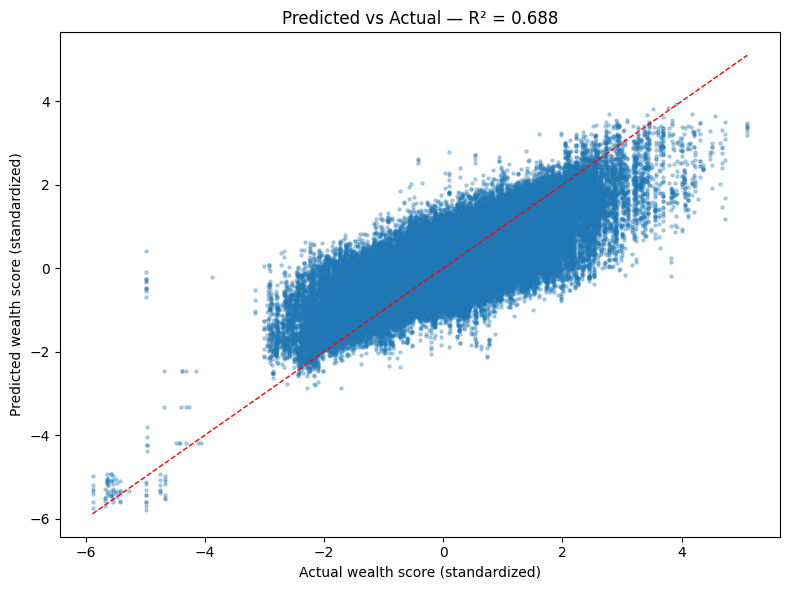

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha = 0.3, s=5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1)
plt.xlabel('Actual wealth score (standardized)')
plt.ylabel('Predicted wealth score (standardized)')
plt.title(f'Predicted vs Actual — R² = {r2:.3f}')
plt.tight_layout()
plt.show()

In [21]:
feature_importances = pd.Series(model.feature_importances_, index=features) \
                .sort_values(ascending=False)

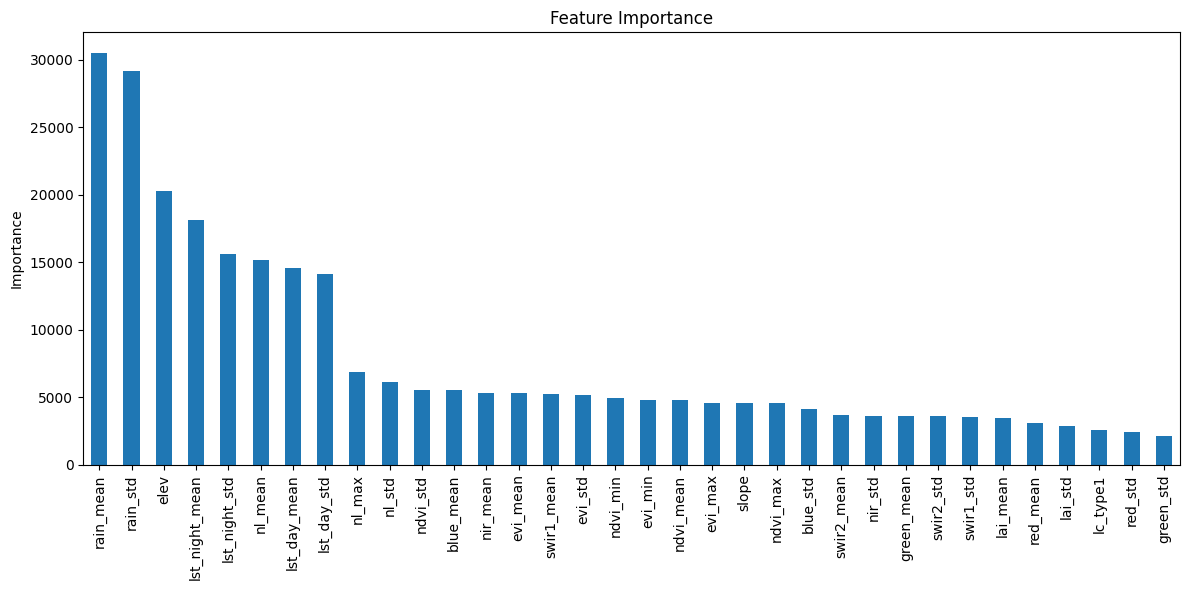

In [22]:
plt.figure(figsize=(12,6))
feature_importances.plot(kind='bar')
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [23]:
print("\nTop 10 important features:")
feature_importances.head(10)


Top 10 important features:


rain_mean         30509
rain_std          29136
elev              20305
lst_night_mean    18145
lst_night_std     15576
nl_mean           15188
lst_day_mean      14593
lst_day_std       14104
nl_max             6874
nl_std             6130
dtype: int32

In [61]:
grid_files = glob.glob(r'C:\Users\makis\Downloads\GEE_25KM_RICH\*.csv')
grid_dfs = []
for f in grid_files:
    df_temp=pd.read_csv(f)
    df_temp['region'] = f.split('v2_')[-1].replace('.csv', '')
    grid_dfs.append(df_temp)

print(grid_dfs[-1]['region'])

0        oceania
1        oceania
2        oceania
3        oceania
4        oceania
          ...   
17170    oceania
17171    oceania
17172    oceania
17173    oceania
17174    oceania
Name: region, Length: 17175, dtype: object


In [76]:
df_global = pd.concat(grid_dfs, ignore_index = True)

# Sparse over arid areas — impute with 0 (physically correct)
arid_sparse = ['rain_mean', 'rain_std', 'lai_mean', 'lai_std']
for col in arid_sparse:
    df_global[col] = df_global[col].fillna(0)

# Nightlights — impute with 0 (dark = no lights)
for col in ['nl_mean', 'nl_max', 'nl_std']:
    df_global[col] = df_global[col].fillna(0)

# For remaining nulls — use median of nearby pixels
# This handles isolated gaps without distorting predictions
for col in features:
    median_val = df_global[col].median()
    df_global[col] = df_global[col].fillna(median_val)

# Now no dropna needed
print(f"Total rows: {len(df_global):,}")
print(f"Remaining nulls: {df_global[features].isnull().sum().sum()}")



Total rows: 192,948
Remaining nulls: 0


In [77]:
# Parse coordinates
df_global['lon'] = df_global['.geo'].apply(
    lambda x: json.loads(x)['coordinates'][0])
df_global['lat'] = df_global['.geo'].apply(
    lambda x: json.loads(x)['coordinates'][1])


In [78]:
df_global['predicted_wealth'] = model.predict(df_global[features])

In [79]:
print("\n Prediction summary:")
print(df_global['predicted_wealth'].describe())


 Prediction summary:
count    192948.000000
mean         -0.145716
std           0.592204
min          -6.052872
25%          -0.482095
50%          -0.133981
75%           0.239260
max           2.625683
Name: predicted_wealth, dtype: float64


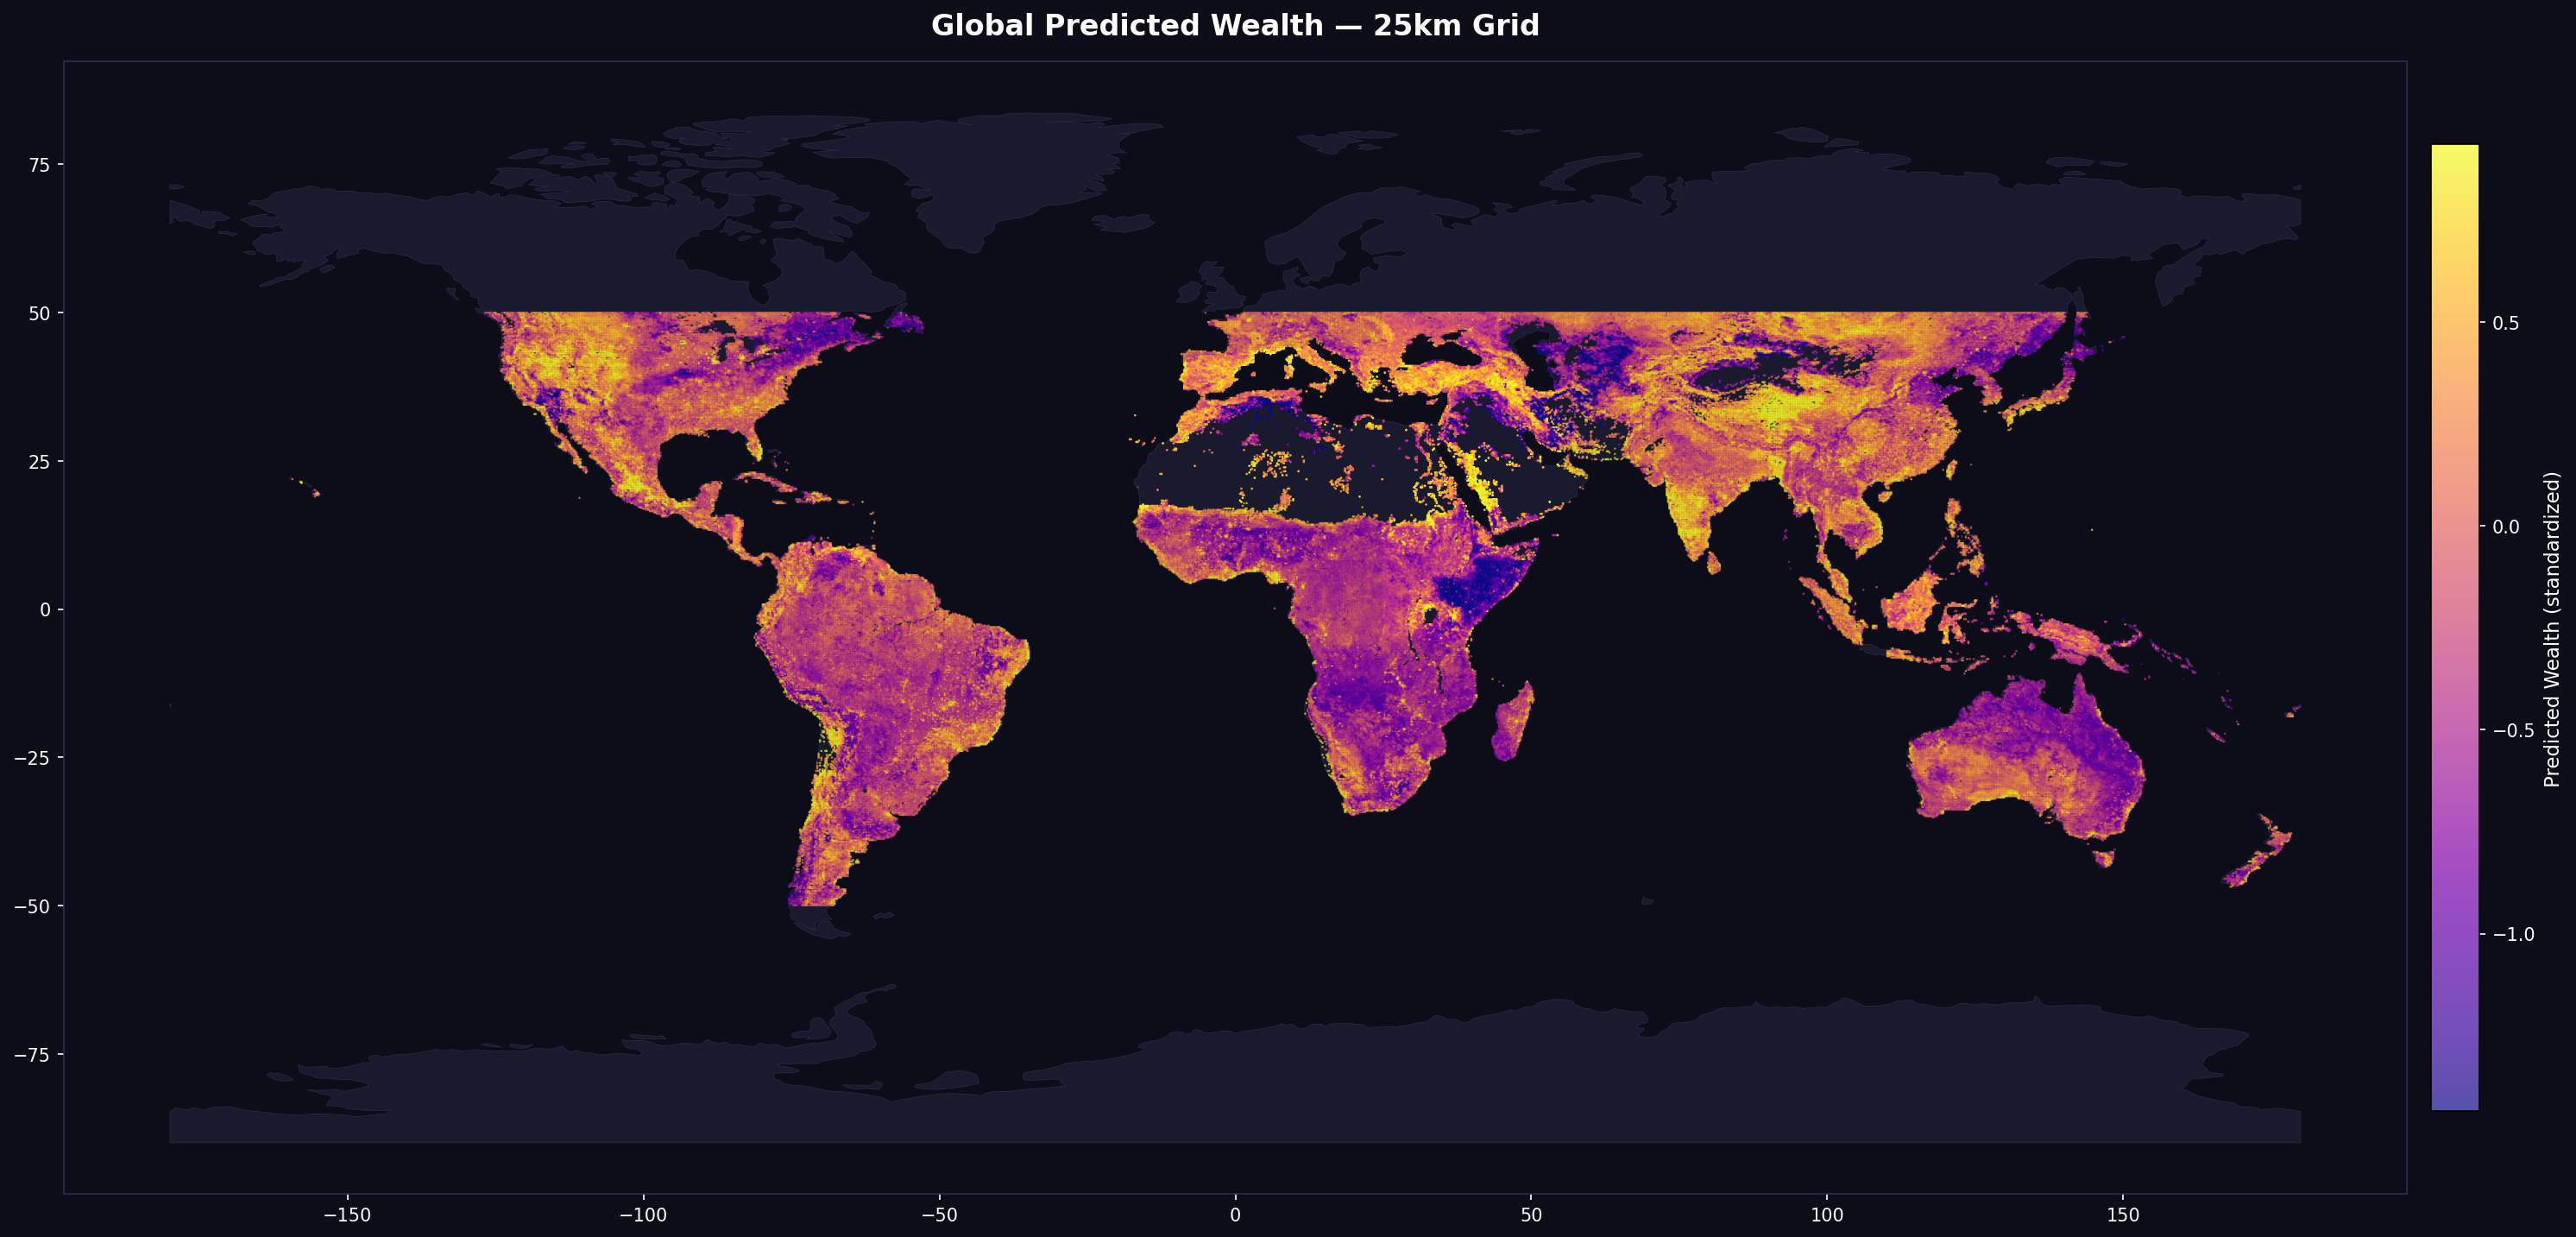

In [80]:
#Global map

import geopandas as gpd
import geodatasets

low  = df_global['predicted_wealth'].quantile(0.02)
high = df_global['predicted_wealth'].quantile(0.98)
df_global['wealth_clipped'] = df_global['predicted_wealth'].clip(low, high)

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

fig, ax = plt.subplots(figsize=(20, 10), dpi=150)
world.plot(ax=ax, color='#1a1a2e', edgecolor='#2d2d4e', linewidth=0.3)
ax.set_facecolor('#0d0d1a')
fig.patch.set_facecolor('#0d0d1a')

scatter = ax.scatter(
    df_global['lon'], df_global['lat'],
    c=df_global['wealth_clipped'],
    cmap='plasma', s=1.5, alpha=0.7, linewidths=0
)

cbar = plt.colorbar(scatter, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('Predicted Wealth (standardized)', color='white', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Global Predicted Wealth — 25km Grid',
             color='white', fontsize=16, fontweight='bold', pad=15)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d2d4e')

plt.tight_layout()
plt.show()